<h2><center>MNIST classification using <i>LeNet5</i></center></h2>

In [ ]:
#!pip install tensorflow==2.8.0

# Importing Keras

In [1]:
# Importing the Keras main module relying on tensorflow backend
import tensorflow as tf
import keras
print("Using tensorflow version " + str(tf.__version__))
print("Using keras version " + str(keras.__version__))

Using tensorflow version 2.21.0
Using keras version 3.14.0


# Loading and preparing the MNIST dataset

In [2]:
#@title
# The MNSIT dataset is ready to be imported from Keras into RAM
# Warning: you cannot do that for larger databases (e.g., ImageNet)
from keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
print(train_images.shape)
print(test_images.shape)
print(train_labels.shape)
print(test_labels.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


Label for 0-th train image is: 5


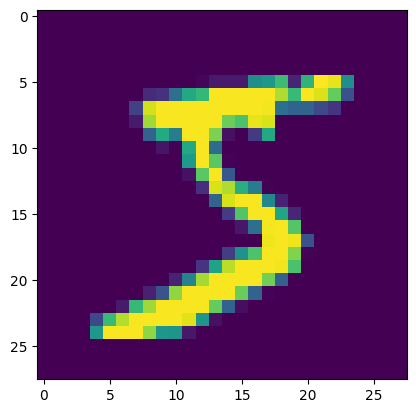

In [3]:
# Let us visualize the first training sample using the Gnuplot library
from matplotlib import pyplot as plt
imageIndex = 0
print("Label for " + str(imageIndex) + "-th train image is: " + str(train_labels[0]))
plt.imshow(train_images[0])

In [4]:
# Turning the lables into one-hot format
from keras.utils import to_categorical
#imageIndex = 0
#print("This is the native " + str(imageIndex) + "-th train label: " + str(train_labels[0]))
train_labels = to_categorical(train_labels)
#print("This is the one-hot encoding of the " + str(imageIndex) + "-th train label: " + str(train_labels[0]))
test_labels = to_categorical(test_labels)

In [6]:
# Reshaping the images to NWHC scheme
img_rows, img_cols = train_images.shape[1], train_images.shape[2]
train_images = train_images.reshape(train_images.shape[0], img_rows, img_cols, 1)
test_images = test_images.reshape(test_images.shape[0], img_rows, img_cols,1 )
print('train_images shape:', train_images.shape)
print('test_images shape:', test_images.shape)
#print(train_images.shape[0], 'train samples')
#print(test_images.shape[0], 'test samples')

# Cast pixels from uint8 to float32
train_images = train_images.astype('float32')
test_images = test_images.astype('float32')

# Normalize the images so that have zero mean and unitary deviation wrt the train set
train_mean = train_images.mean()
train_std = train_images.std()
train_images = (train_images - train_mean)/train_std
test_images = (test_images - train_mean)/train_std

# Alternatively, we could squeeze the pixel intensities in the [0-1] range instead
#train_images = train_images / 255
#test_images = test_images / 255

train_images shape: (60000, 28, 28, 1)
test_images shape: (10000, 28, 28, 1)


# Defining the neural network architecture (i.e., the network model)
Create a LeNet5-like convolutional neural network taking in input the images as matrices of pixels and suitable to classify each image across 10 different classes.

In [ ]:
# The Sequential module is sort of a container for more complex NN elements and
# defines a loop-less NN architecture
from keras.models import Sequential
from keras.layers import Input, Dense, Activation, Flatten, Convolution2D, MaxPooling2D

input_shape = (img_rows, img_cols, 1)

# size of pooling area for max pooling
pool_size = (2, 2)
# convolution kernel size
kernel_size = (5, 5)
# Number of filters in first convolutional layer
num_kernel_first_conv_layer = 6
# Number of filters in second convolutional layer
num_kernel_second_conv_layer = 16

model = Sequential()

model.add(Input(input_shape))
model.add(Convolution2D(num_kernel_first_conv_layer, kernel_size))
model.add(Activation('sigmoid'))
model.add(MaxPooling2D(pool_size=pool_size))

model.add(Convolution2D(num_kernel_second_conv_layer, kernel_size))
model.add(Activation('sigmoid'))
model.add(MaxPooling2D(pool_size=pool_size))

# Turns the sequence of featuremaps into a linear array of features
model.add(Flatten())
model.add(Dense(100))
model.add(Activation('sigmoid'))
model.add(Dense(10))
model.add(Activation('softmax'))

Instantiate a SGD optimizer with a tentative LR of 10^-3 and using the appropriate loss function and compile the model.

In [8]:
# The optimizers module provides a number of optimization algorithms for updating
# a netwok parameters accoridng to the computed error gradints
from keras import optimizers

# Defining our optimizer
optimizer=tf.optimizers.SGD(learning_rate=1e-2)

model.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])

# Let us have a look at the model topology
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 24, 24, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        25,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,282 (114.38 KB)

 Trainable params: 29,282 (114.38 KB)

 Non-trainable params: 0 (0.00 B)

# Training the network - fit()

In [ ]:
# This is where the actual training-testing happens
# Dimension of the batch size (number of images over which error gradients are averaged)
batch_size = 20
# Number of epochs we want to train
epochs = 20
history=model.fit(train_images, train_labels,
          batch_size=batch_size, epochs=epochs,
          verbose=1, shuffle=True, validation_data=(test_images, test_labels))

# Training the network - train_on_batch()

In [ ]:
# This is where the actual training-testing happens
# Dimension of the batch size (number of images over which error gradients are averaged)
batch_size = 20
# Number of epochs we want to train
epochs = 20

#For being able to plot the training history afterwards
history = {}
history['loss'] = []
history['val_loss'] = []
history['acc'] = []
history['val_acc'] = []

# Creating a batch preprocessor for augmenting the trainig data
from tensorflow.keras.preprocessing.image import ImageDataGenerator
myDatagen = ImageDataGenerator()
# Compute quantities required for feature-wise normalization
myDatagen.fit(train_images)

# Cycling through the epochs
for e in range(epochs):
    lossEpochTrain = 0
    lossEpochTest = 0
    accuracyEpochTrain = 0
    accuracyEpochTest = 0

    # Training over the training samlpes, batch by batch
    batchCnt = 0
    for images_batch, labels_batch in myDatagen.flow(train_images, train_labels, batch_size=batch_size):
        batch_history = model.train_on_batch(images_batch, labels_batch)
        lossBatch = batch_history[0]
        lossEpochTrain += lossBatch
        accuracyBatch = batch_history[1]
        accuracyEpochTrain += accuracyBatch
        batchCnt += 1
        print ('\r  Epoch %d / %d trainBatch %d / %d loss %.3f accuracy %.3f' %(int(e), epochs, batchCnt, len(train_images) / batch_size, lossBatch, accuracyBatch), end = '')
        # break the loop or generator loops indefinitely
        if batchCnt >= len(train_images) / batch_size:
            break
    print("")

    # Testing over the training samlpes, batch by batch
    batchCntTest = 0
    for images_batch, labels_batch in myDatagen.flow(test_images, test_labels, batch_size=batch_size):
        batch_history = model.test_on_batch(images_batch, labels_batch)
        #lossEpochTest += batch_history[0]
        #accuracyEpochTest += batch_history[1]
        lossBatchTest = batch_history[0]
        lossEpochTest += lossBatchTest
        accuracyBatchTest = batch_history[1]
        accuracyEpochTest += accuracyBatchTest
        batchCntTest += 1
        print ('\r  Epoch %d / %d testBatch %d / %d loss %.3f accuracy %.3f' %(int(e), epochs, batchCntTest, len(test_images) / batch_size, lossBatchTest, accuracyBatchTest), end = '')
        # break the loop or generator loops indefinitely
        if batchCntTest >= len(test_images) / batch_size:
            break
    print("")

    print ('Epoch %d / %d lossTrain %.3f lossTest %.3f accuracyTrain %.3f accuracyTest %.3f' %(int(e), epochs, lossEpochTrain/batchCnt, lossEpochTest/batchCnt, accuracyEpochTrain/batchCnt, accuracyEpochTest/batchCnt))
    history['loss'].append(lossEpochTrain/batchCnt)
    history['val_loss'].append(lossEpochTest/batchCntTest)
    history['acc'].append(accuracyEpochTrain/batchCnt)
    history['val_acc'].append(accuracyEpochTest/batchCntTest)

#Training the network - apply_gradients()

In [ ]:
# This is where the actual training-testing happens
# Dimension of the batch size (number of images over which error gradients are averaged)
batch_size = 20
# Number of epochs we want to train
epochs = 20

#For being able to plot the training history afterwards
history = {}
history['loss'] = []
history['val_loss'] = []
history['acc'] = []
history['val_acc'] = []

# Creating a batch preprocessor for augmenting the trainig data
from tensorflow.keras.preprocessing.image import ImageDataGenerator
myDatagen = ImageDataGenerator()
# Compute quantities required for feature-wise normalization
myDatagen.fit(train_images)

# Our loss function
loss_fn = keras.losses.CategoricalCrossentropy()

# Accuracy calculated using Keras' method
accuracy = tf.keras.metrics.CategoricalAccuracy()

# Cycling through the epochs
for e in range(epochs):
    lossEpochTrain = 0
    lossEpochTest = 0
    accuracyEpochTrain = 0
    accuracyEpochTest = 0

    # Training over the training samlpes, batch by batch
    batchCnt = 0
    for images_batch, labels_batch in myDatagen.flow(train_images, train_labels, batch_size=batch_size):
        #https://keras.io/guides/writing_a_training_loop_from_scratch/
        with tf.GradientTape() as tape:
            output_batch = model(images_batch, training=True)  # Logits for this minibatch
            # Compute the loss value for this minibatch.
            lossBatch = loss_fn(output_batch, labels_batch);
            lossEpochTrain += lossBatch
        # Gradients of the loss wrt the trainable variables
        grads = tape.gradient(lossBatch, model.trainable_weights)
        # Run one step of gradient descent by updating the value of the variables to minimize the loss.
        optimizer.apply_gradients(zip(grads, model.trainable_weights))

        # Computing the accuracy on a single train batch
        accuracy.update_state(output_batch, labels_batch)
        accuracyBatch = accuracy.result().numpy()
        #print(accuracyBatch)
        accuracyEpochTrain += accuracyBatch
        batchCnt += 1
        #print ('\r  Epoch %d / %d trainBatch %d / %d loss %.3f accuracy %.3f' %(int(e), epochs, batchCnt, len(train_images) / batch_size, lossBatch, accuracyBatch), end = '')
        # break the loop or generator loops indefinitely
        if batchCnt >= len(train_images) / batch_size:
            break
    print("")

    # Testing over the training samlpes, batch by batch
    batchCntTest = 0
    for images_batch, labels_batch in myDatagen.flow(test_images, test_labels, batch_size=batch_size):
        batch_history = model.test_on_batch(images_batch, labels_batch)
        #lossEpochTest += batch_history[0]
        #accuracyEpochTest += batch_history[1]
        lossBatchTest = batch_history[0]
        lossEpochTest += lossBatchTest
        accuracyBatchTest = batch_history[1]
        accuracyEpochTest += accuracyBatchTest
        batchCntTest += 1
        print ('\r  Epoch %d / %d testBatch %d / %d loss %.3f accuracy %.3f' %(int(e), epochs, batchCntTest, len(test_images) / batch_size, lossBatchTest, accuracyBatchTest), end = '')
        # break the loop or generator loops indefinitely
        if batchCntTest >= len(test_images) / batch_size:
            break
    print("")

    print ('Epoch %d / %d lossTrain %.3f lossTest %.3f accuracyTrain %.3f accuracyTest %.3f' %(int(e), epochs, lossEpochTrain/batchCnt, lossEpochTest/batchCnt, accuracyEpochTrain/batchCnt, accuracyEpochTest/batchCnt))
    history['loss'].append(lossEpochTrain/batchCnt)
    history['val_loss'].append(lossEpochTest/batchCntTest)
    history['acc'].append(accuracyEpochTrain/batchCnt)
    history['val_acc'].append(accuracyEpochTest/batchCntTest)

# Visualizing the network performance

In [ ]:
# We now want to plot the train and validation loss functions and accuracy curves
#print(history.history.keys())

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.ylim(top=3)
plt.ylim(bottom=0)
plt.xlabel('Epoch')
plt.xlim(left=0)
plt.xlim(right=10)
plt.legend(['train', 'test'], loc='upper right')
plt.show()

# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.ylim(top=1)
plt.ylim(bottom=0)
plt.xlabel('Epoch')
plt.xlim(left=0)
plt.xlim(right=10)
plt.legend(['train', 'test'], loc='lower right')
plt.show()


# Experiments

Note down the performance of the trained network in terms of training and validation accuracy as a reference. Then, experiment as follow and compare performance with the reference scenario.

*   **Hidden layers activations**: experiment replacing sigmoids with ReLUs.
*   **Filter size**: experiment with (stacks of) square filters of size 3x3 so to obtain equivalent filters 5x5.
*   **Number of filters**: experiment increasing the number of filters in the first and second layer and find the maximum number of filters the network can tolerate before overfitting to the training samples.
* **Pooling-less architectures**: Modify the network architecture to obtain a twofold reduction of each featuremap without resorting to pooling layers (hint: take insipiration from ResNet).
* **Confusion analysis**: Using the proper metric  from sklearn, check which character is most frequently confused with which: can you explain why ?


In [ ]:
# Example of a confusion matrix using sklearn.metrics
from sklearn.metrics import confusion_matrix
predictions = model.predict(test_images)
# Mind that confusion_matrix requires
matrix = confusion_matrix(test_labels.argmax(axis=1), predictions.argmax(axis=1))
print (matrix)

#Saving the training results

Save the best trained model (topology, parameters), and all the related side information required to deploy the trained model later on.


In [ ]:
# Create a directory for saving both the trained model and side information
import os
save_dir = os.path.join(os.getcwd(), 'trained_lenet5_mnist')
if not os.path.isdir(save_dir):
    os.makedirs(save_dir)

# Save model and weights
model_name = 'model.h5'
model_path = os.path.join(save_dir, model_name)
model.save(model_path)
print('Saved trained model at %s ' % model_path)

# Saving mean and standard deviation information as a CSV file
import csv
model_name = 'std_dev.csv'
model_path = os.path.join(save_dir, model_name)
w = csv.writer(open(model_path, "w"))
dict={}
dict['mean'] = train_mean
dict['std'] = train_std
for key, val in dict.items():
    w.writerow([key, val])
print('Saved side information at %s ' % model_path)